<a href="https://colab.research.google.com/github/anshupandey83/PRODIGY_ML_03/blob/main/Cats_Dogs_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import userdata
import os

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

print("Kaggle authentication configured successfully.")

Kaggle authentication configured successfully.


In [2]:
!pip -q install kaggle

In [3]:
!kaggle competitions download -c dogs-vs-cats

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFiles


In [4]:
!pip install -q --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 4.2 MB/s eta 0:00:00


In [6]:
!kaggle competitions download -c dogs-vs-cats

100% 812M/812M [00:14<00:00, 59.7MB/s]



In [7]:
import os

print(os.listdir('/content'))

['.config', 'dogs-vs-cats.zip', 'sample_data']


In [8]:
!unzip -q /content/dogs-vs-cats.zip -d /content/dogs_vs_cats

In [9]:
import os

print(os.listdir('/content/dogs_vs_cats'))

['test1.zip', 'sampleSubmission.csv', 'train.zip']


In [10]:
!unzip -q /content/dogs_vs_cats/train.zip -d /content/dogs_vs_cats/train

In [11]:
import os

print("Total images:", len(os.listdir('/content/dogs_vs_cats/train/train')))
print(os.listdir('/content/dogs_vs_cats/train/train')[:10])

Total images: 25000
['dog.11783.jpg', 'cat.11615.jpg', 'cat.10254.jpg', 'cat.5945.jpg', 'cat.11396.jpg', 'cat.4684.jpg', 'dog.6012.jpg', 'dog.7688.jpg', 'cat.8382.jpg', 'dog.2487.jpg']


In [12]:
import os
import glob

train_path = "/content/dogs_vs_cats/train/train"

cat_images = glob.glob(train_path + "/cat.*.jpg")
dog_images = glob.glob(train_path + "/dog.*.jpg")

print("Cats:", len(cat_images))
print("Dogs:", len(dog_images))

Cats: 12500
Dogs: 12500


In [13]:
import random

random.seed(42)

cat_selected = random.sample(cat_images, 2500)
dog_selected = random.sample(dog_images, 2500)

image_paths = cat_selected + dog_selected
labels = [0] * 2500 + [1] * 2500

print("Total selected images:", len(image_paths))
print("Cats:", labels.count(0))
print("Dogs:", labels.count(1))

Total selected images: 5000
Cats: 2500
Dogs: 2500


In [14]:
from PIL import Image
import numpy as np

X = []

for path in image_paths:
    img = Image.open(path).convert("RGB")
    img = img.resize((64, 64))
    X.append(np.array(img).flatten())

X = np.array(X)
y = np.array(labels)

print("Feature shape:", X.shape)
print("Labels shape:", y.shape)

Feature shape: (5000, 12288)
Labels shape: (5000,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4000, 12288)
Testing data: (1000, 12288)


In [16]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Normalization complete!")
print("Min:", X_train.min())
print("Max:", X_train.max())

Normalization complete!
Min: 0.0
Max: 1.0


In [17]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=10, gamma='scale')

svm_model.fit(X_train, y_train)

print("SVM model training completed!")

SVM model training completed!


In [18]:
y_pred = svm_model.predict(X_test)

print("Prediction completed!")
print("First 10 predictions:", y_pred[:10])

Prediction completed!
First 10 predictions: [0 1 0 0 1 0 0 1 0 0]


In [19]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Cat", "Dog"]))

Accuracy: 0.62

Classification Report:
              precision    recall  f1-score   support

         Cat       0.61      0.65      0.63       500
         Dog       0.63      0.59      0.61       500

    accuracy                           0.62      1000
   macro avg       0.62      0.62      0.62      1000
weighted avg       0.62      0.62      0.62      1000



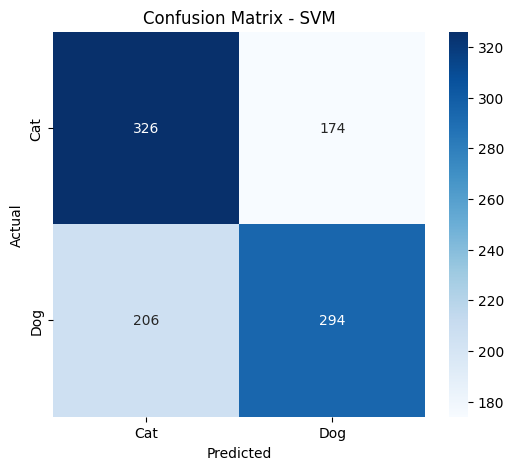

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Cat', 'Dog'],
    yticklabels=['Cat', 'Dog']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM')
plt.show()

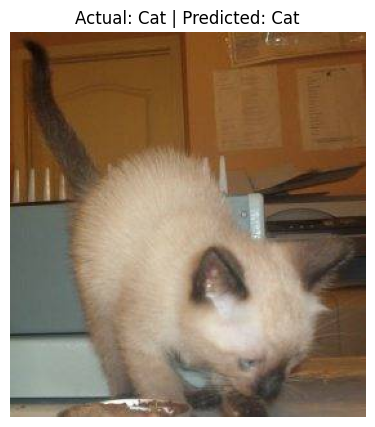

In [21]:
import matplotlib.pyplot as plt
from PIL import Image

index = 0

img = Image.open(image_paths[index])

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")

actual = "Cat" if y_test[0] == 0 else "Dog"
predicted = "Cat" if y_pred[0] == 0 else "Dog"

plt.title(f"Actual: {actual} | Predicted: {predicted}")
plt.show()

In [22]:
import joblib

joblib.dump(svm_model, '/content/svm_cat_dog_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [23]:
import os

model_path = "/content/svm_cat_dog_model.pkl"

print("Model exists:", os.path.exists(model_path))
print("Model size:", round(os.path.getsize(model_path) / (1024 * 1024), 2), "MB")

Model exists: True
Model size: 348.82 MB
